**Red Neuronal Convolucional (CNN) con TensorFlow**

Descripción del problema de clasificación

El objetivo de esta práctica es implementar una Red Neuronal Convolucional (CNN) utilizando TensorFlow y Keras para resolver un problema de clasificación de imágenes.

En este ejemplo se utilizará el dataset MNIST, el cual contiene imágenes de dígitos escritos a mano del 0 al 9.

Cada imagen:

Tiene tamaño de 28x28 píxeles.
Está en escala de grises.
Pertenece a una de 10 clases.

La CNN aprenderá automáticamente características relevantes de las imágenes mediante capas convolucionales y de pooling para posteriormente realizar la clasificación.

**Pipeline**

**Exploración y preprocesamiento del Dataset**
Importar librerías

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

**Cargar el dataset MNIST**

In [2]:
# Cargar dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

print("Training images shape:", train_images.shape)
print("Testing images shape:", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)


**Visualización de imágenes**

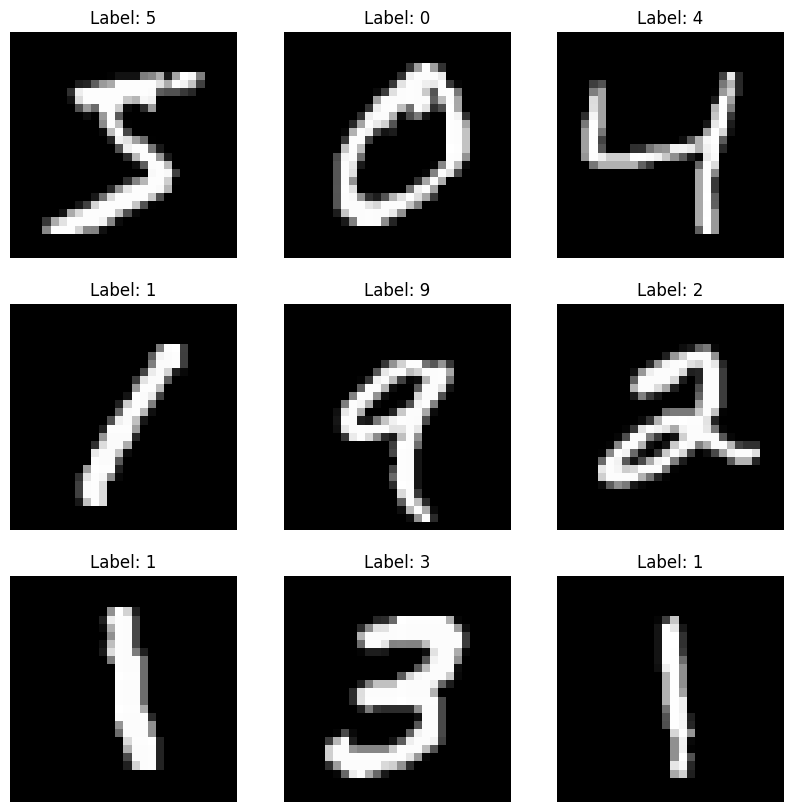

In [5]:
# Mostrar algunas imágenes
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title("Label: {}".format(train_labels[i]))
    plt.axis('off')

plt.show()

**Normalización de imágenes**

La normalización ayuda a mejorar el entrenamiento de la red neuronal.

In [4]:
# Normalizar valores entre 0 y 1
train_images = train_images / 255.0
test_images = test_images / 255.0

**Redimensionar imágenes para CNN**

Las CNN requieren un canal adicional.

In [6]:
# Agregar dimensión del canal
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

print(train_images.shape)

(60000, 28, 28, 1)


**CNN Architecture**
Construcción de la CNN

In [7]:
# Crear modelo secuencial
model = models.Sequential()

# Primera capa convolucional
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(28,28,1)))

# Pooling
model.add(layers.MaxPooling2D((2,2)))

# Segunda capa convolucional
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Segundo pooling
model.add(layers.MaxPooling2D((2,2)))

# Tercera capa convolucional
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Aplanar datos
model.add(layers.Flatten())

# Capa densa
model.add(layers.Dense(64, activation='relu'))

# Capa de salida
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resumen del modelo

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Explicación de la arquitectura

La arquitectura implementada contiene:

Capas convolucionales:
Extraen características importantes.
Capas MaxPooling:
Reducen dimensionalidad.
Flatten:
Convierte matrices a vectores.
Dense:
Realiza la clasificación final.
Softmax:
Genera probabilidades para las 10 clases.

**Model Training**
Compilar el modelo

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Entrenamiento del modelo

In [11]:
history = model.fit(train_images,
                    train_labels,
                    epochs=5,
                    validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9552 - loss: 0.1450 - val_accuracy: 0.9831 - val_loss: 0.0547
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9855 - loss: 0.0457 - val_accuracy: 0.9878 - val_loss: 0.0388
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9898 - loss: 0.0323 - val_accuracy: 0.9901 - val_loss: 0.0315
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 0.9856 - val_loss: 0.0478
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9933 - loss: 0.0195 - val_accuracy: 0.9911 - val_loss: 0.0306


**Visualización del accuracy**

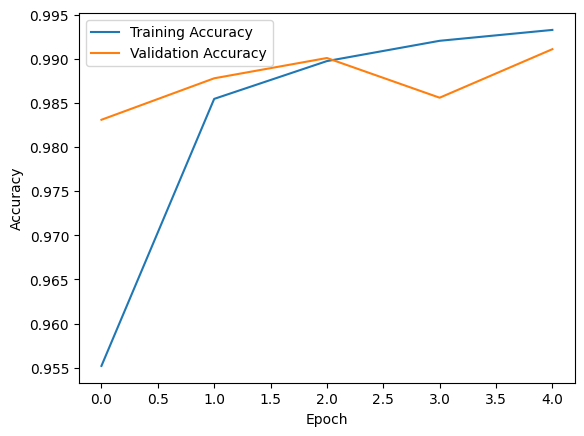

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Model Prediction
Realizar predicciones

In [14]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


**Predicción de una imagen**

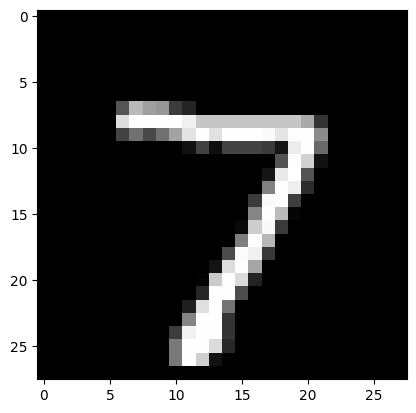

Predicción: 7
Etiqueta real: 7


In [15]:
# Mostrar imagen
plt.imshow(test_images[0].reshape(28,28), cmap='gray')
plt.show()

# Clase predicha
predicted_class = np.argmax(predictions[0])

print("Predicción:", predicted_class)
print("Etiqueta real:", test_labels[0])


Evaluar el modelo

In [16]:
test_loss, test_acc = model.evaluate(test_images,
                                     test_labels,
                                     verbose=2)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 - 3s - 9ms/step - accuracy: 0.9911 - loss: 0.0306
Test Accuracy: 0.991100013256073
Test Loss: 0.03064858354628086


Matriz de confusión

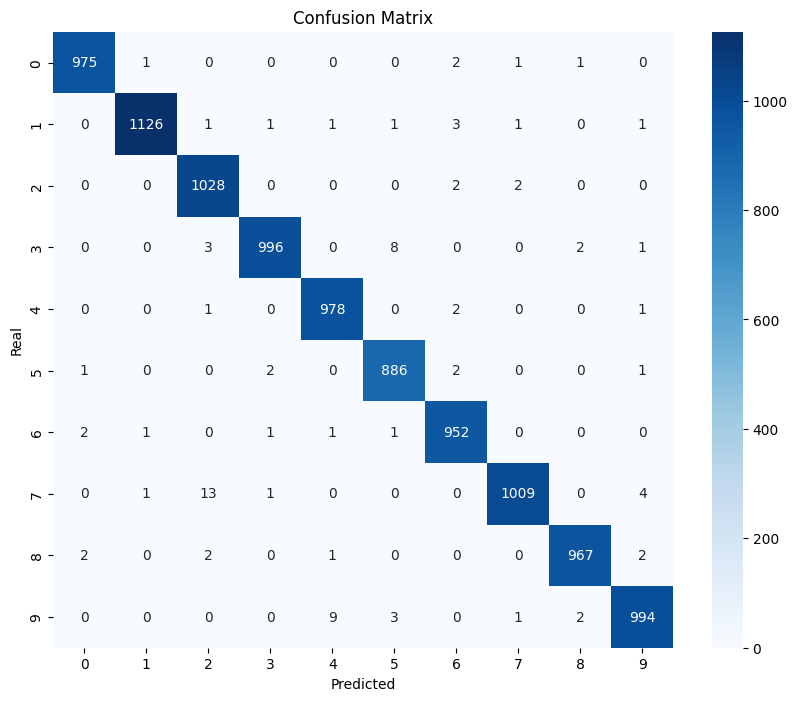

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener predicciones finales
y_pred = np.argmax(predictions, axis=1)

# Matriz de confusión
cm = confusion_matrix(test_labels, y_pred)

# Visualización
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')

plt.show()

Model Storing (Almacenamiento del modelo)
Guardar modelo entrenado

In [18]:
model.save("cnn_mnist_model.h5")

print("Modelo guardado correctamente")

Modelo guardado correctamente


Cargar modelo almacenado

In [19]:
from tensorflow.keras.models import load_model

new_model = load_model("cnn_mnist_model.h5")

print("Modelo cargado correctamente")

Modelo cargado correctamente


Conclusión

En esta práctica se implementó una Red Neuronal Convolucional utilizando TensorFlow/Keras para resolver un problema de clasificación de imágenes.

La CNN logró aprender características importantes del dataset MNIST mediante capas convolucionales y pooling, obteniendo una alta precisión en la clasificación de dígitos escritos a mano.

Además, se desarrolló todo el pipeline de Machine Learning:

Exploración de datos.
Preprocesamiento.
Diseño de arquitectura CNN.
Entrenamiento.
Predicción.
Evaluación.
Almacenamiento del modelo.

Este tipo de arquitecturas son ampliamente utilizadas en:

Visión computacional.
Reconocimiento facial.
Vehículos autónomos.
Diagnóstico médico.
Sistemas inteligentes.